##Load & Overview Data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import subprocess
from pathlib import Path
from nbconvert import HTMLExporter
warnings.filterwarnings('ignore')

In [2]:
# Konfigurasi tampilan plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Load dataset yang sudah dibersihkan
df = pd.read_csv('../data/processed/dataset_stunting_clean.csv')

print("=" * 60)
print("OVERVIEW DATASET STUNTING")
print("=" * 60)
print(f"\n📌 Shape       : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"📌 Kolom       : {list(df.columns)}")
print(f"\n📌 Tipe Data:")
print(df.dtypes)
print(f"\n📌 5 Baris Pertama:")
df.head()

OVERVIEW DATASET STUNTING

📌 Shape       : 40066 baris x 11 kolom
📌 Kolom       : ['id_anak', 'jenis_kelamin', 'usia_bulan', 'berat_badan', 'tinggi_badan', 'status_bb_u', 'zscore_bb_u', 'status_tb_u', 'zscore_tb_u', 'status_bb_tb', 'zscore_bb_tb']

📌 Tipe Data:
id_anak            int64
jenis_kelamin        str
usia_bulan       float64
berat_badan      float64
tinggi_badan     float64
status_bb_u          str
zscore_bb_u      float64
status_tb_u          str
zscore_tb_u      float64
status_bb_tb         str
zscore_bb_tb     float64
dtype: object

📌 5 Baris Pertama:


,id_anak,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_bb_u,zscore_bb_u,status_tb_u,zscore_tb_u,status_bb_tb,zscore_bb_tb
0,1,Perempuan,54.0,13.2,97.5,Normal,-1.94,Stunting,-2.11,Normal,-0.95
1,2,Laki-laki,44.0,12.0,92.0,Normal,-1.92,Stunting,-2.22,Normal,-0.88
2,3,Laki-laki,57.0,14.0,97.0,Normal,-1.90,Stunting,-2.58,Normal,-0.48
3,4,Laki-laki,26.0,11.0,79.0,Normal,-1.15,Stunting,-3.11,Normal,0.68
4,5,Perempuan,59.0,14.6,98.0,Normal,-1.66,Stunting,-2.49,Normal,-0.18


##Cek Missing Values & Duplikasi

In [3]:
print("=" * 60)
print("PENGECEKAN MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})
print(missing_df[missing_df['Jumlah Missing'] > 0])

PENGECEKAN MISSING VALUES
Empty DataFrame
Columns: [Jumlah Missing, Persentase (%)]
Index: []


In [4]:
def save_fig(filename):
    #Simpan figure, otomatis buat folder jika belum ada.
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"✅ Tersimpan: {filename}")

✅ Tersimpan: ../reports/figures/missing_values_heatmap.png


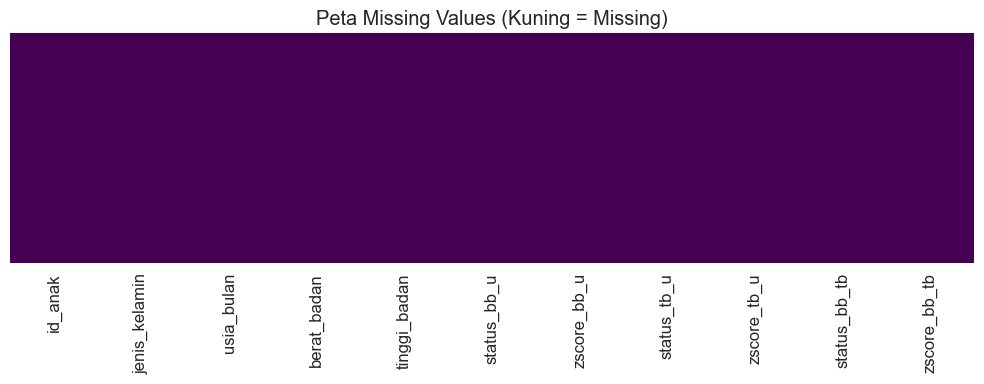


📌 Jumlah Duplikasi : 0 baris


In [5]:
# Visualisasi missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Peta Missing Values (Kuning = Missing)')
plt.tight_layout()
save_fig('../reports/figures/missing_values_heatmap.png')
plt.show()

# Duplikasi
print(f"\n📌 Jumlah Duplikasi : {df.duplicated().sum()} baris")

##Statistik Deskriptif

In [6]:
kolom_numerik = ['usia_bulan', 'berat_badan', 'tinggi_badan',
                'zscore_bb_u', 'zscore_tb_u', 'zscore_bb_tb']

# Paksa konversi ke numerik, nilai yang tidak bisa dikonversi jadi NaN
for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cek tipe data setelah konversi
print("📌 Tipe data setelah konversi:")
print(df[kolom_numerik].dtypes)
print(f"\n📌 Cek nilai non-numerik yang jadi NaN:")
print(df[kolom_numerik].isnull().sum())

📌 Tipe data setelah konversi:
usia_bulan      float64
berat_badan     float64
tinggi_badan    float64
zscore_bb_u     float64
zscore_tb_u     float64
zscore_bb_tb    float64
dtype: object

📌 Cek nilai non-numerik yang jadi NaN:
usia_bulan      0
berat_badan     0
tinggi_badan    0
zscore_bb_u     0
zscore_tb_u     0
zscore_bb_tb    0
dtype: int64


In [7]:
# Statistik deskriptif
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF - VARIABEL NUMERIK")
print("=" * 60)

desc = df[kolom_numerik].describe().T
desc['skewness'] = df[kolom_numerik].skew(numeric_only=True).round(3)
desc['kurtosis'] = df[kolom_numerik].kurt(numeric_only=True).round(3)
print(desc.round(3))


STATISTIK DESKRIPTIF - VARIABEL NUMERIK
                count    mean     std    min    25%    50%    75%      max  \
usia_bulan    40066.0  33.020  15.823   0.00  20.00  34.00  47.00    60.00   
berat_badan   40066.0  11.660  29.506   2.00   9.50  11.50  13.40  3100.00   
tinggi_badan  40066.0  86.052  11.816  44.00  78.00  87.30  95.20   120.00   
zscore_bb_u   40066.0  -0.933  44.470  -5.80  -1.92  -1.34  -0.80  4622.49   
zscore_tb_u   40066.0  -1.736   1.185  -7.27  -2.46  -1.80  -1.04     6.60   
zscore_bb_tb  40066.0   0.182  75.051  -5.89  -1.20  -0.61   0.02  7657.39   

              skewness   kurtosis  
usia_bulan      -0.138     -1.052  
berat_badan     99.028   9902.192  
tinggi_badan    -0.499     -0.189  
zscore_bb_u    100.332  10089.820  
zscore_tb_u      0.428      2.114  
zscore_bb_tb   100.068  10015.627  


##Distribusi Variabel Numerik

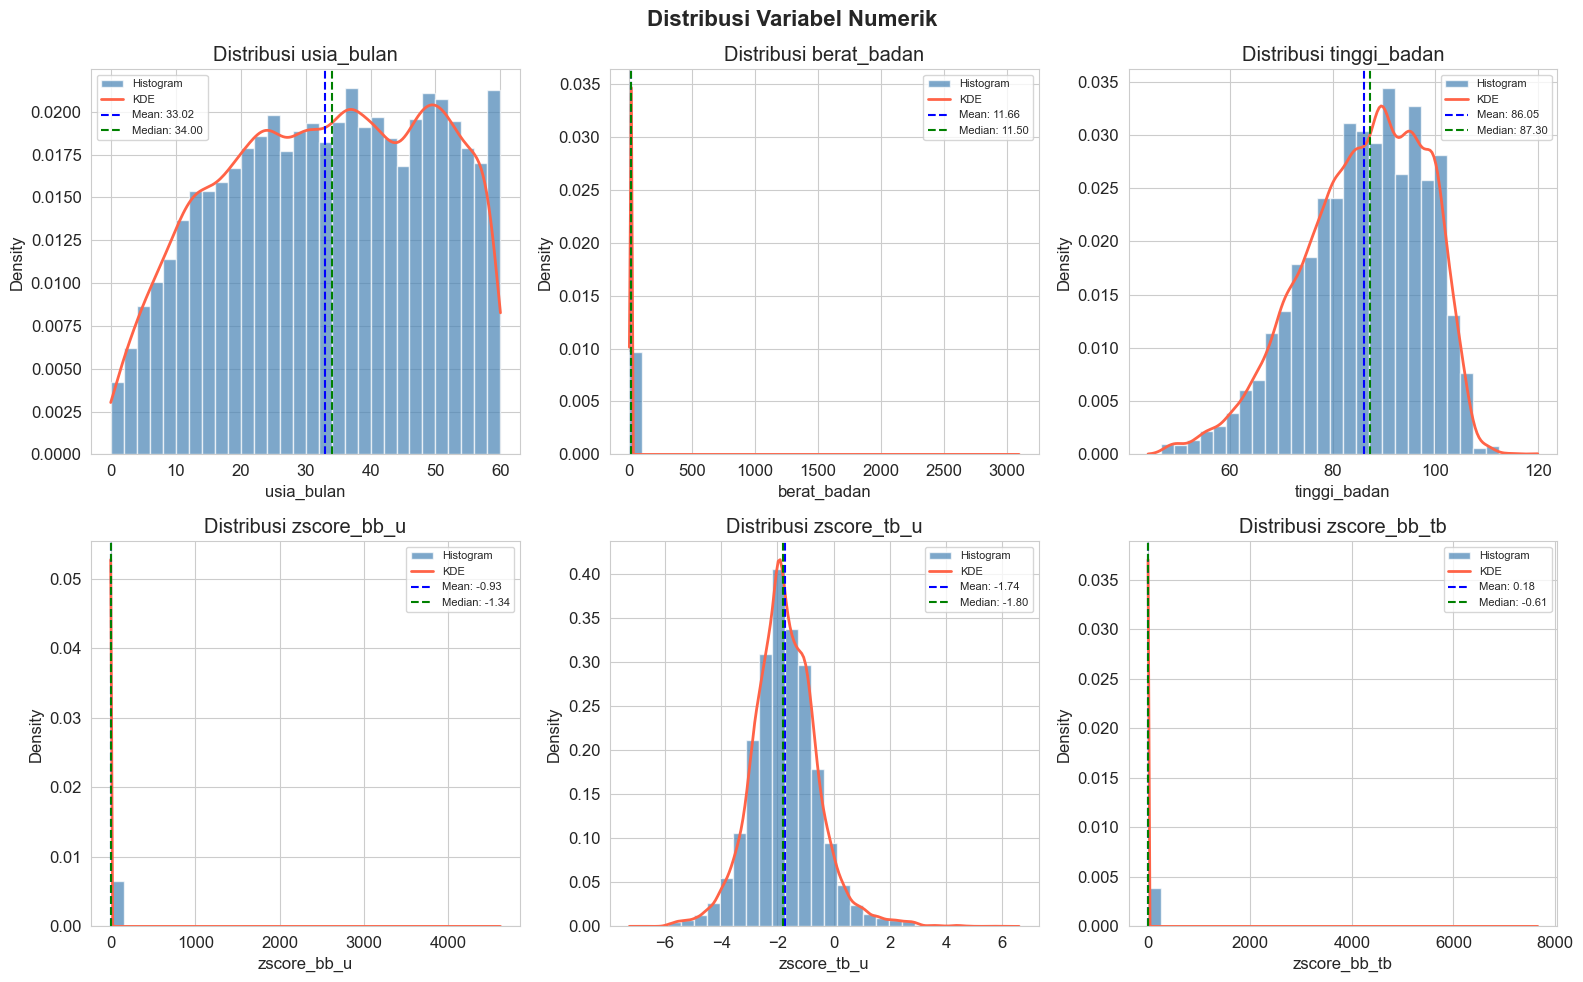

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    ax = axes[i]
    data = df[col].dropna()

    # Histogram + KDE
    ax.hist(data, bins=30, color='steelblue', edgecolor='white',
            alpha=0.7, density=True, label='Histogram')

    # KDE line
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color='tomato', lw=2, label='KDE')

    # Garis mean & median
    ax.axvline(data.mean(), color='blue', ls='--', lw=1.5,
            label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', ls='--', lw=1.5,
            label=f'Median: {data.median():.2f}')

    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Variabel Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/distribusi_numerik.png', dpi=150)
plt.show()

##Distribusi Variabel Kategorik

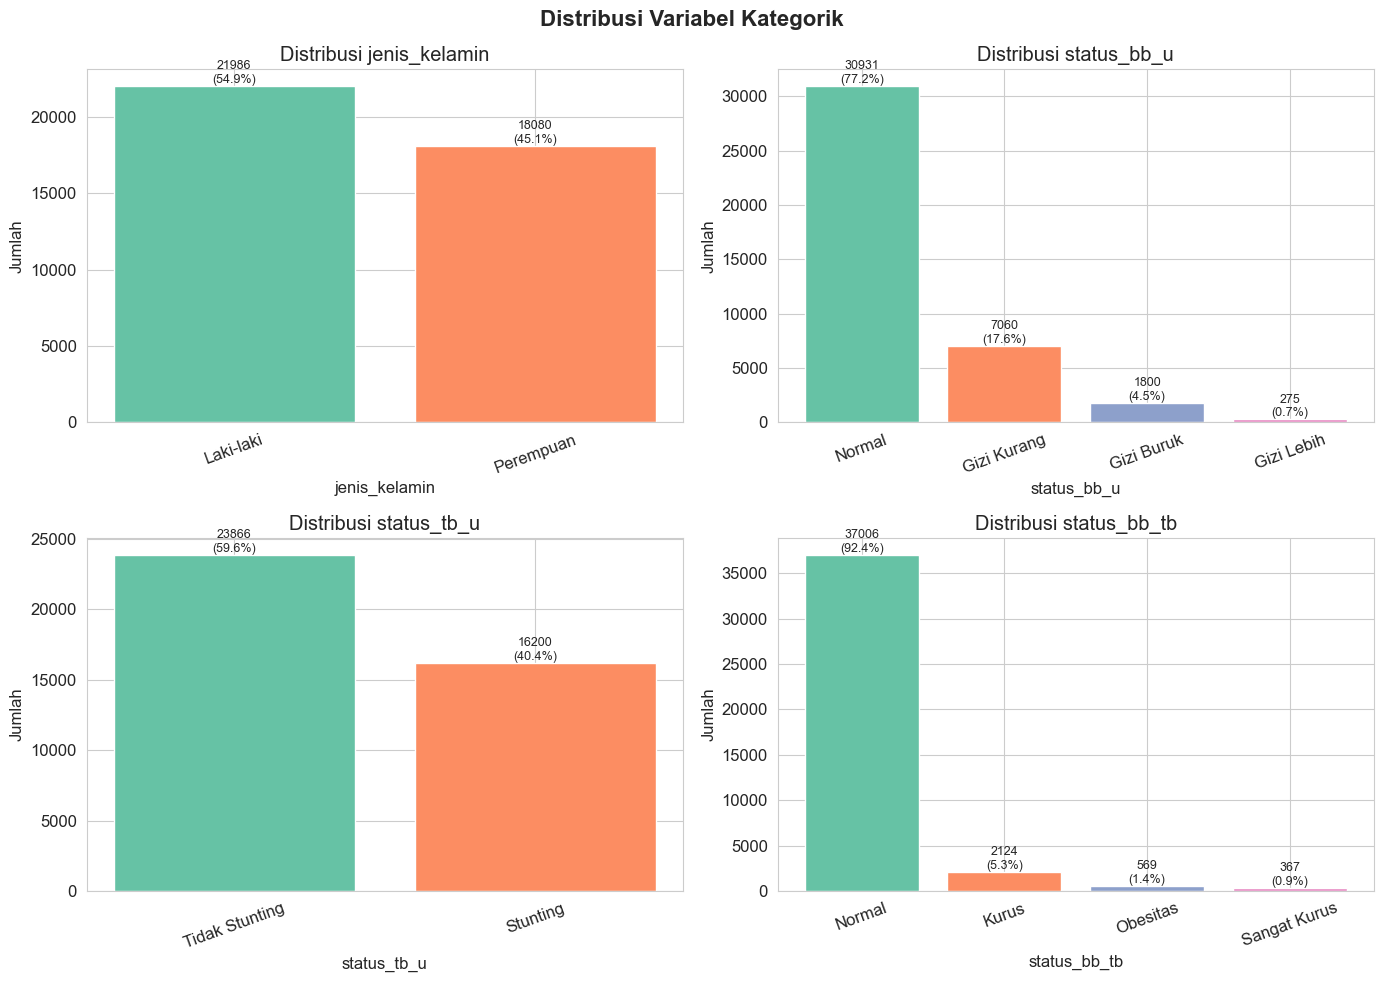

In [9]:
kolom_kategorik = ['jenis_kelamin', 'status_bb_u', 'status_tb_u', 'status_bb_tb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_kategorik):
    ax = axes[i]
    value_counts = df[col].value_counts()
    colors = sns.color_palette("Set2", len(value_counts))

    bars = ax.bar(value_counts.index, value_counts.values, color=colors, edgecolor='white')

    # Tambahkan label jumlah & persentase di atas bar
    for bar, val in zip(bars, value_counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribusi Variabel Kategorik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/distribusi_kategorik.png', dpi=150)
plt.show()

In [10]:
# Print proporsi
for col in kolom_kategorik:
    print(f"\n📌 Proporsi {col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


📌 Proporsi jenis_kelamin:
jenis_kelamin
Laki-laki    54.87%
Perempuan    45.13%
Name: proportion, dtype: str

📌 Proporsi status_bb_u:
status_bb_u
Normal          77.2%
Gizi Kurang    17.62%
Gizi Buruk      4.49%
Gizi Lebih      0.69%
Name: proportion, dtype: str

📌 Proporsi status_tb_u:
status_tb_u
Tidak Stunting    59.57%
Stunting          40.43%
Name: proportion, dtype: str

📌 Proporsi status_bb_tb:
status_bb_tb
Normal          92.36%
Kurus             5.3%
Obesitas         1.42%
Sangat Kurus     0.92%
Name: proportion, dtype: str


##Analisis Stunting (Variabel Target)

ANALISIS STATUS STUNTING (status_tb_u)


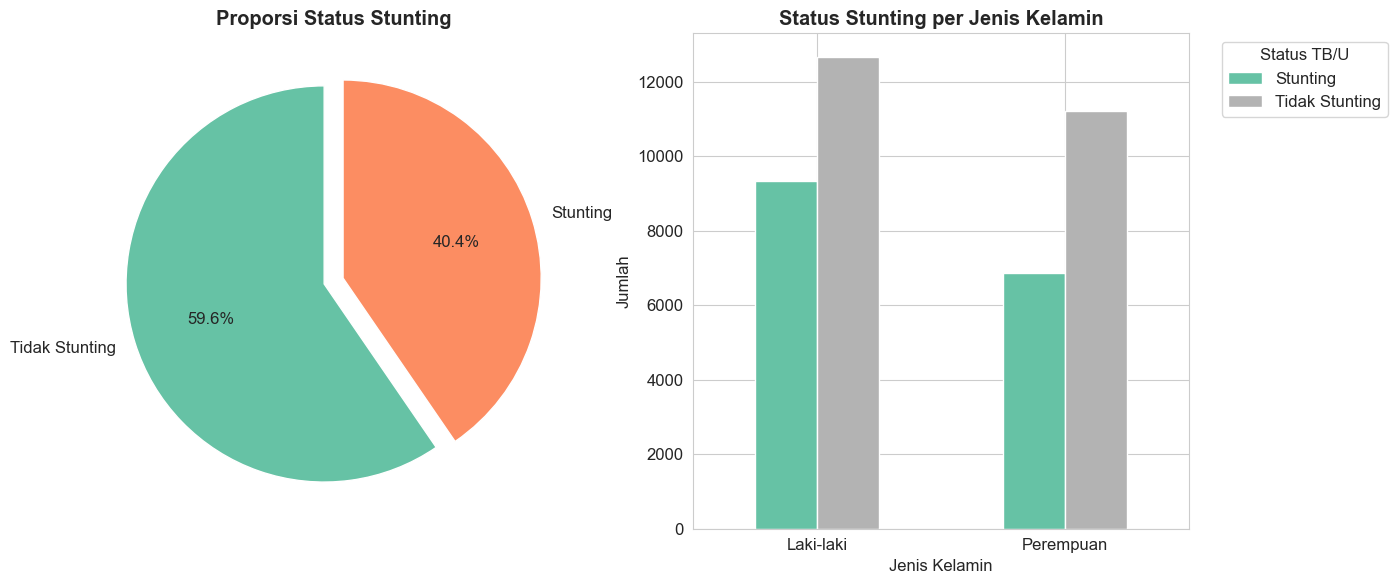

In [11]:
print("=" * 60)
print("ANALISIS STATUS STUNTING (status_tb_u)")
print("=" * 60)

# Pie chart status stunting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
stunting_counts = df['status_tb_u'].value_counts()
axes[0].pie(
    stunting_counts.values,
    labels=stunting_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2", len(stunting_counts)),
    explode=[0.05] * len(stunting_counts)
)
axes[0].set_title('Proporsi Status Stunting', fontweight='bold')

# Bar berdasarkan jenis kelamin
stunting_gender = df.groupby(['jenis_kelamin', 'status_tb_u']).size().unstack(fill_value=0)
stunting_gender.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Status Stunting per Jenis Kelamin', fontweight='bold')
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status TB/U', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('../reports/figures/analisis_stunting.png', dpi=150)
plt.show()

##Analisis Berdasarkan Kelompok Usia

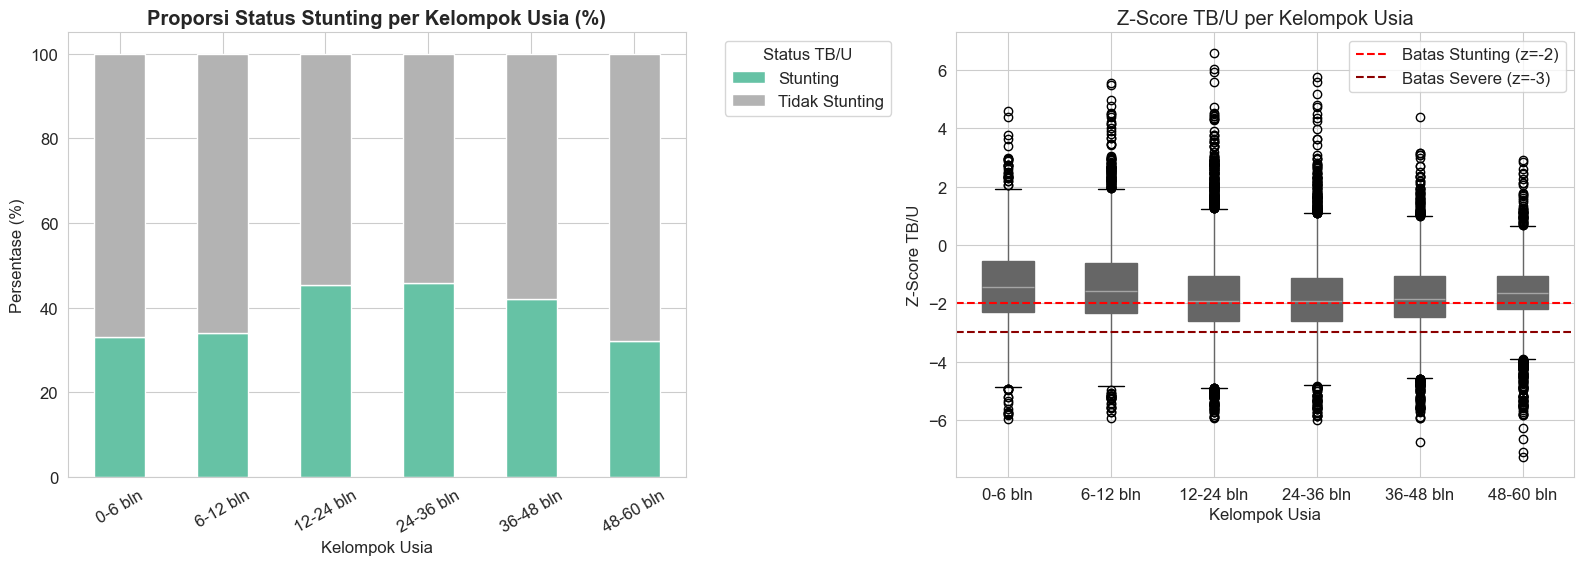

In [12]:
# Buat kelompok usia
bins = [0, 6, 12, 24, 36, 48, 60]
labels = ['0-6 bln', '6-12 bln', '12-24 bln', '24-36 bln', '36-48 bln', '48-60 bln']
df['kelompok_usia'] = pd.cut(df['usia_bulan'], bins=bins, labels=labels, right=True)

# Prevalensi stunting per kelompok usia
stunting_usia = df.groupby('kelompok_usia')['status_tb_u'].value_counts(normalize=True).unstack(fill_value=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
stunting_usia.plot(kind='bar', stacked=True, ax=axes[0],
                colormap='Set2', edgecolor='white')
axes[0].set_title('Proporsi Status Stunting per Kelompok Usia (%)', fontweight='bold')
axes[0].set_xlabel('Kelompok Usia')
axes[0].set_ylabel('Persentase (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Status TB/U', bbox_to_anchor=(1.05, 1))

# Z-score TB/U per kelompok usia (boxplot)
df.boxplot(column='zscore_tb_u', by='kelompok_usia', ax=axes[1],
        patch_artist=True)
axes[1].axhline(y=-2, color='red', ls='--', lw=1.5, label='Batas Stunting (z=-2)')
axes[1].axhline(y=-3, color='darkred', ls='--', lw=1.5, label='Batas Severe (z=-3)')
axes[1].set_title('Z-Score TB/U per Kelompok Usia')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Z-Score TB/U')
axes[1].legend()
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/stunting_per_usia.png', dpi=150)
plt.show()

##Korelasi Antar Variabel Numerik

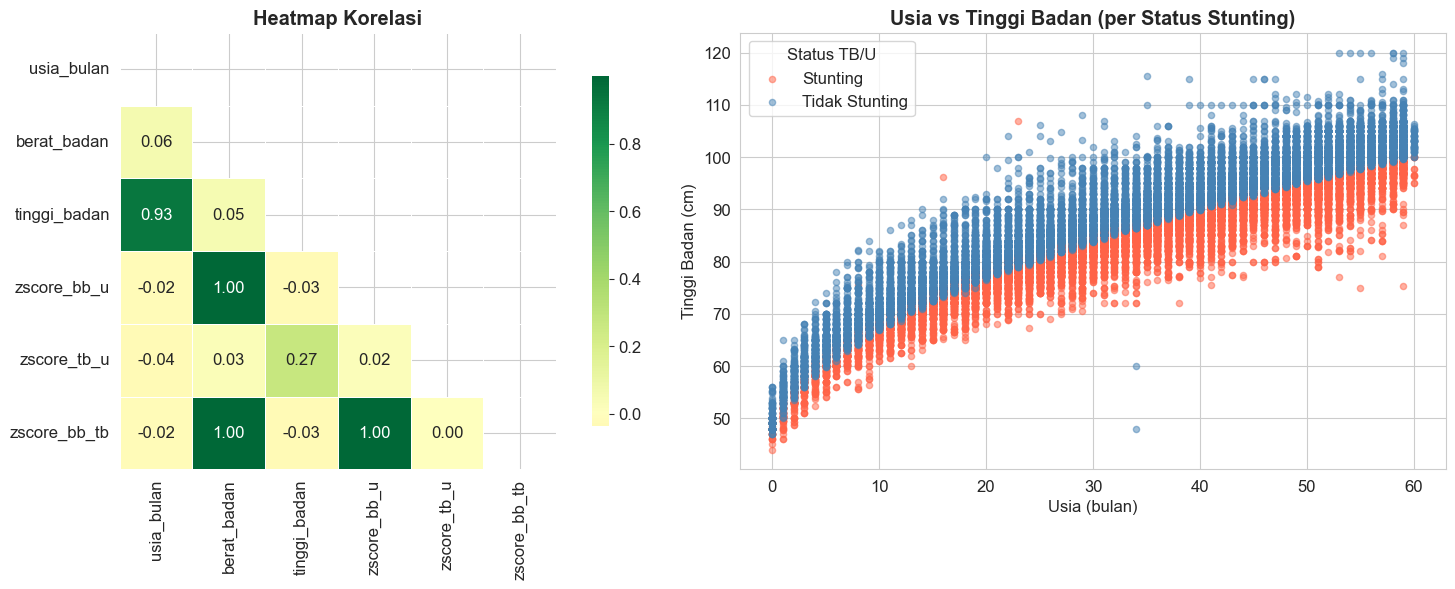

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap korelasi
corr_matrix = df[kolom_numerik].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=axes[0],
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title('Heatmap Korelasi', fontweight='bold')

# Scatter: usia vs tinggi badan, diwarnai status stunting
scatter_data = df.dropna(subset=['usia_bulan', 'tinggi_badan', 'status_tb_u'])
colors_map = {
    'Tidak Stunting': 'steelblue',
    'Stunting': 'tomato',
    'Severely Stunted': 'darkred'
}
for status, group in scatter_data.groupby('status_tb_u'):
    axes[1].scatter(group['usia_bulan'], group['tinggi_badan'],
                    label=status, alpha=0.5, s=20,
                    color=colors_map.get(status, 'gray'))
axes[1].set_title('Usia vs Tinggi Badan (per Status Stunting)', fontweight='bold')
axes[1].set_xlabel('Usia (bulan)')
axes[1].set_ylabel('Tinggi Badan (cm)')
axes[1].legend(title='Status TB/U')

plt.tight_layout()
plt.savefig('../reports/figures/korelasi_scatter.png', dpi=150)
plt.show()

In [14]:
print("\n📌 Top Korelasi Tertinggi:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(8).round(3))


📌 Top Korelasi Tertinggi:
zscore_bb_tb  zscore_bb_u     0.999
berat_badan   zscore_bb_u     0.995
zscore_bb_tb  berat_badan     0.995
usia_bulan    tinggi_badan    0.927
tinggi_badan  zscore_tb_u     0.271
berat_badan   usia_bulan      0.059
              tinggi_badan    0.054
zscore_tb_u   berat_badan     0.026
dtype: float64


##Boxplot & Outlier Detection

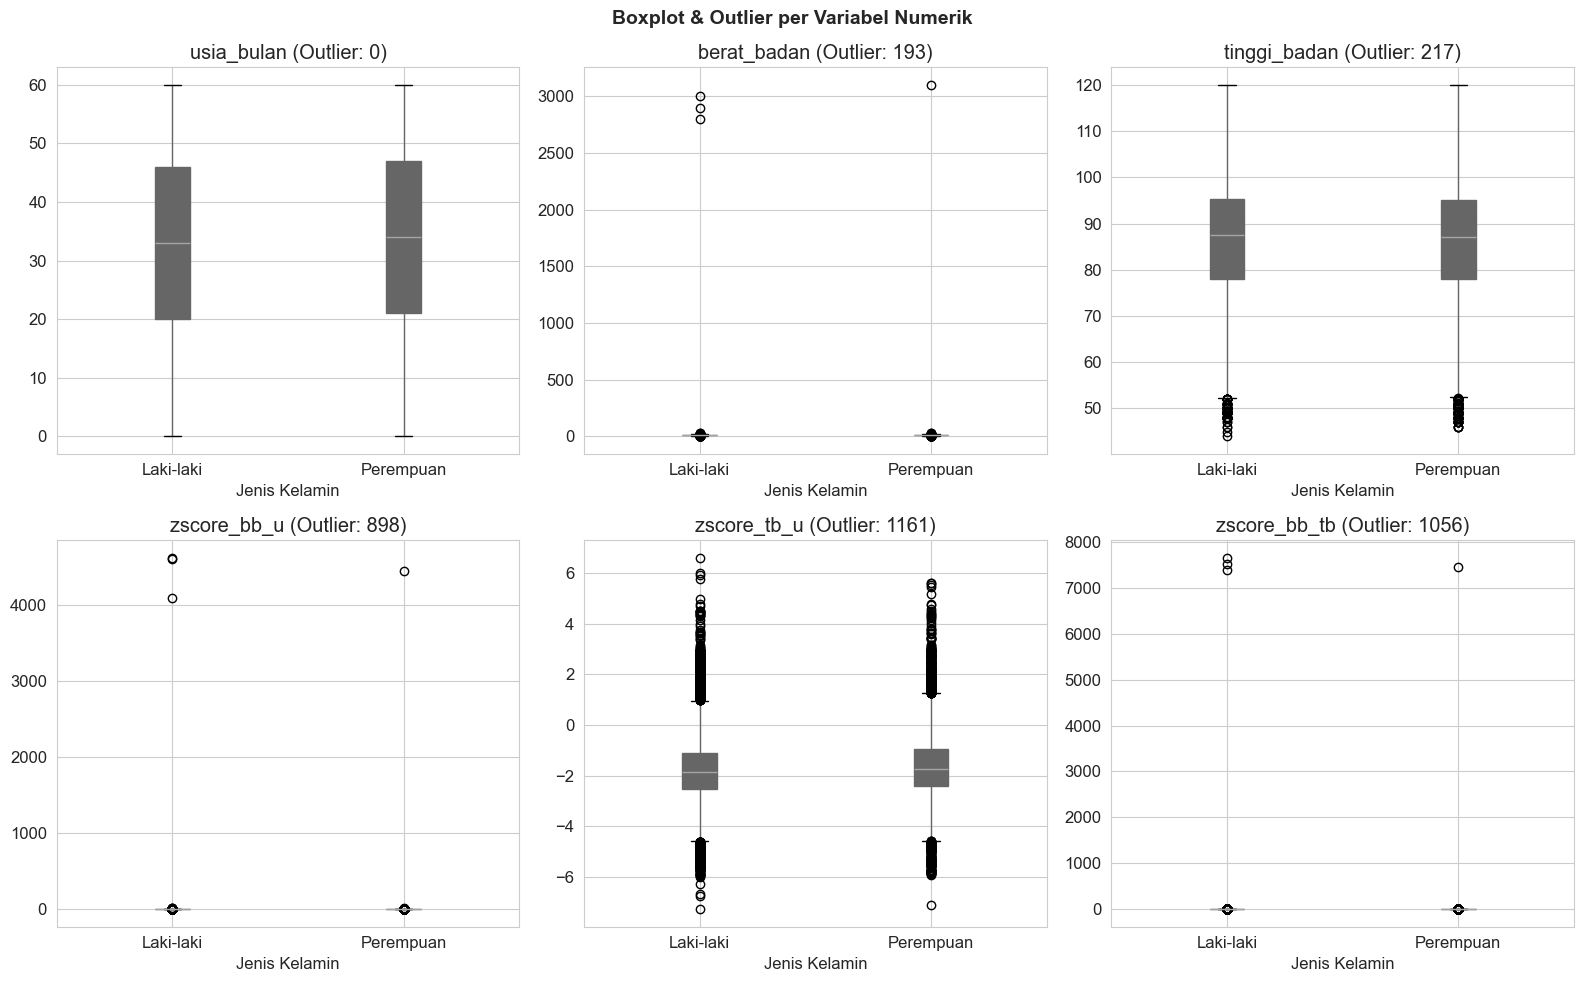

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    ax = axes[i]
    data = df[col].dropna()

    # Boxplot per jenis kelamin
    df.boxplot(column=col, by='jenis_kelamin', ax=ax, patch_artist=True)

    # Hitung outlier (IQR)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]

    ax.set_title(f'{col}\n(Outlier: {len(outliers)} data)')
    ax.set_xlabel('Jenis Kelamin')
    plt.sca(ax)
    plt.title(f'{col} (Outlier: {len(outliers)})')

plt.suptitle('Boxplot & Outlier per Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/boxplot_outlier.png', dpi=150)
plt.show()

In [16]:
# Summary outlier
print("\n📌 Ringkasan Outlier per Kolom:")
for col in kolom_numerik:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = len(data[(data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)])
    print(f"  {col:20s}: {n_out} outlier ({n_out/len(data)*100:.2f}%)")


📌 Ringkasan Outlier per Kolom:
  usia_bulan          : 0 outlier (0.00%)
  berat_badan         : 193 outlier (0.48%)
  tinggi_badan        : 217 outlier (0.54%)
  zscore_bb_u         : 898 outlier (2.24%)
  zscore_tb_u         : 1161 outlier (2.90%)
  zscore_bb_tb        : 1056 outlier (2.64%)


##Ringkasan EDA & Simpan Laporan

In [17]:
print("\n" + "=" * 60)
print("RINGKASAN HASIL EDA")
print("=" * 60)

print(f"\n📊 Total Data        : {len(df):,} anak")
print(f"📊 Jenis Kelamin     :")
print(df['jenis_kelamin'].value_counts().to_string())
print(f"\n📊 Rentang Usia      : {df['usia_bulan'].min():.0f} - {df['usia_bulan'].max():.0f} bulan")
print(f"📊 Rata-rata Usia    : {df['usia_bulan'].mean():.1f} bulan")
print(f"\n📊 Status Stunting (TB/U):")
print(df['status_tb_u'].value_counts().to_string())
print(f"\n📊 Prevalensi Stunting: {(df['status_tb_u'] == 'Stunting').mean()*100:.2f}%")
print(f"\n📊 Rata-rata Z-Score TB/U : {df['zscore_tb_u'].mean():.3f}")
print(f"📊 Rata-rata BB (kg)      : {df['berat_badan'].mean():.2f}")
print(f"📊 Rata-rata TB (cm)      : {df['tinggi_badan'].mean():.2f}")

print("\n✅ EDA selesai! Semua visualisasi tersimpan di '/content/'")


RINGKASAN HASIL EDA

📊 Total Data        : 40,066 anak
📊 Jenis Kelamin     :
jenis_kelamin
Laki-laki    21986
Perempuan    18080

📊 Rentang Usia      : 0 - 60 bulan
📊 Rata-rata Usia    : 33.0 bulan

📊 Status Stunting (TB/U):
status_tb_u
Tidak Stunting    23866
Stunting          16200

📊 Prevalensi Stunting: 40.43%

📊 Rata-rata Z-Score TB/U : -1.736
📊 Rata-rata BB (kg)      : 11.66
📊 Rata-rata TB (cm)      : 86.05

✅ EDA selesai! Semua visualisasi tersimpan di '/content/'


In [30]:
notebook_path = Path('EDA.ipynb').resolve()
reports_dir = Path('../reports/').resolve()
output_file = reports_dir / 'EDA_report.html'

print(f"Notebook: {notebook_path}")
print(f"Output: {output_file}")

try:
    # Convert notebook ke HTML
    exporter = HTMLExporter(exclude_input=True)
    body, resources = exporter.from_filename(notebook_path)
    
    # Simpan ke file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(body)
    
    print(f'✅ Laporan HTML tersimpan di: {output_file}')
    print(f'✅ File size: {output_file.stat().st_size / 1024:.1f} KB')
except Exception as e:
    print(f'❌ Error: {type(e).__name__}: {e}')

Notebook: D:\Dicoding\capstone-project\SIDIAS-\data_science\notebooks\EDA.ipynb
Output: D:\Dicoding\capstone-project\SIDIAS-\data_science\reports\EDA_report.html
✅ Laporan HTML tersimpan di: D:\Dicoding\capstone-project\SIDIAS-\data_science\reports\EDA_report.html
✅ File size: 1140.7 KB
